# Inland Water Body Detection in Serpentine Lake, London, Using Sentinel-2 Imagery, NDWI and K-means Clustering

## Project Overview

This project investigates whether Sentinel-2 satellite imagery can be used to detect inland water bodies in an urban environment.

The study area is the Serpentine Lake in central London. Water bodies will be identified using the Normalized Difference Water Index (NDWI) and K-means clustering, an unsupervised machine learning technique.

The objective is to compare the performance of NDWI and K-means clustering for detecting inland water bodies in an urban environment.

## 1. Install Packages and Import Libraries

In [3]:
# Install required packages

!pip install earthengine-api geemap rasterio

# Methodology

Sentinel-2 Level-2A imagery was downloaded from the Copernicus Data Space Ecosystem.

A subset covering Hyde Park and the Serpentine Lake was extracted from the full scene.

The analysis focuses on the Green (Band 3) and Near Infrared (Band 8) bands because these bands are required for NDWI calculation.

RGB visualisation was first produced to identify the study area before applying water detection methods.

## 2. Load Sentinel-2 Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio

In [6]:
# Define paths to Sentinel-2 10 m bands

b02_path = "/content/drive/MyDrive/GEOL0069_Project/Sentinel2/S2B_MSIL2A_20260527T105619_N0512_R094_T30UXC_20260527T133135.SAFE/GRANULE/L2A_T30UXC_A048168_20260527T110333/IMG_DATA/R10m/T30UXC_20260527T105619_B02_10m.jp2"

b03_path = b02_path.replace("B02", "B03")  # Green
b04_path = b02_path.replace("B02", "B04")  # Red
b08_path = b02_path.replace("B02", "B08")  # Near infrared

In [20]:
# Crop around central London / Hyde Park area
row_start, row_end = 8750, 9250
col_start, col_end = 9250, 9900

window = rasterio.windows.Window(
    col_start,
    row_start,
    col_end - col_start,
    row_end - row_start
)

with rasterio.open(b02_path) as src:
    blue_crop = src.read(1, window=window).astype("float32")

with rasterio.open(b03_path) as src:
    green_crop = src.read(1, window=window).astype("float32")

with rasterio.open(b04_path) as src:
    red_crop = src.read(1, window=window).astype("float32")

with rasterio.open(b08_path) as src:
    nir_crop = src.read(1, window=window).astype("float32")

print(blue_crop.shape, green_crop.shape, red_crop.shape, nir_crop.shape)

(500, 650) (500, 650) (500, 650) (500, 650)


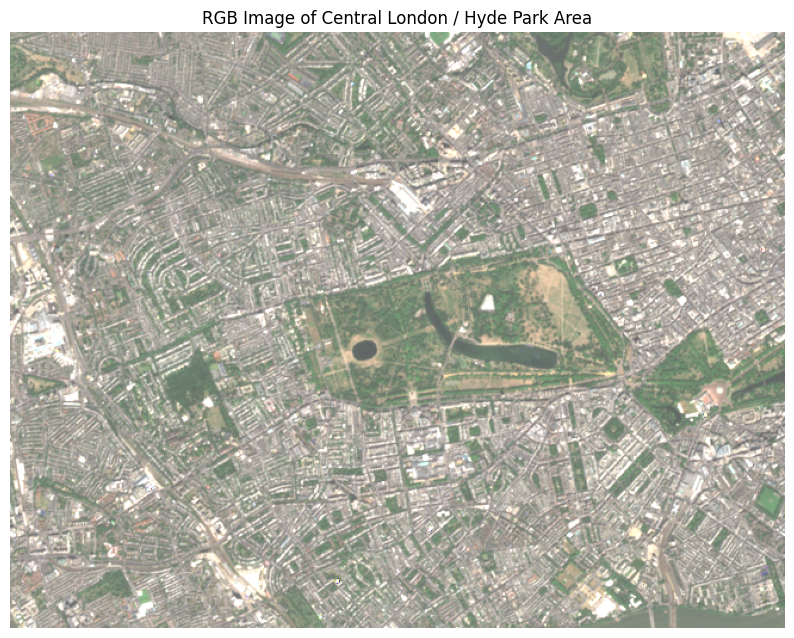

In [21]:
rgb_crop = np.dstack((red_crop, green_crop, blue_crop))
rgb_crop = np.clip(rgb_crop / 3000, 0, 1)

plt.figure(figsize=(10, 8))
plt.imshow(rgb_crop)
plt.title("RGB Image of Central London / Hyde Park Area")
plt.axis("off")
plt.show()

# RGB Visualisation

The RGB image clearly shows Hyde Park and the surrounding urban environment.

The Serpentine Lake can be identified as a dark elongated feature within the park.

This image provides visual confirmation that the selected subset covers the target water body.

In [22]:
# Calculate NDWI for the cropped area

ndwi_crop = (green_crop - nir_crop) / (green_crop + nir_crop + 1e-6)

print("NDWI min:", ndwi_crop.min())
print("NDWI max:", ndwi_crop.max())

NDWI min: -0.8265896
NDWI max: 0.42738506


In [ ]:
# NDWI Analysis

NDWI was calculated using the Green and Near Infrared bands.

Water typically reflects more strongly in the green band and absorbs near infrared radiation, resulting in higher NDWI values.

The NDWI map highlights the Serpentine Lake as one of the brightest features in the study area.

A threshold of NDWI > 0 was used to create a binary water mask.

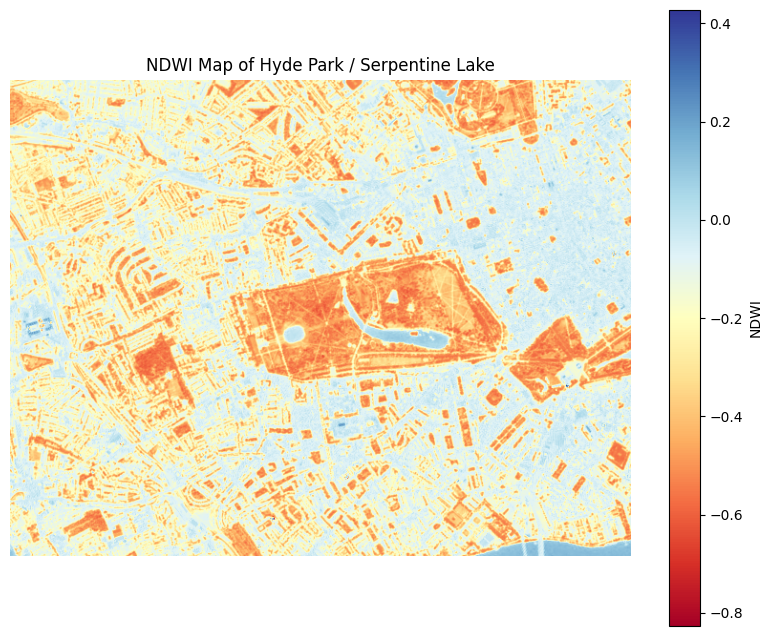

In [23]:
# Display NDWI map

plt.figure(figsize=(10, 8))
plt.imshow(ndwi_crop, cmap="RdYlBu")
plt.colorbar(label="NDWI")
plt.title("NDWI Map of Hyde Park / Serpentine Lake")
plt.axis("off")
plt.show()

In [24]:
from sklearn.cluster import KMeans

In [25]:
# Reshape NDWI image

pixels = ndwi_crop.reshape(-1, 1)

# K-means

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixels)

cluster_map = labels.reshape(ndwi_crop.shape)

print(kmeans.cluster_centers_)

[[-0.11159498]
 [-0.40446645]]


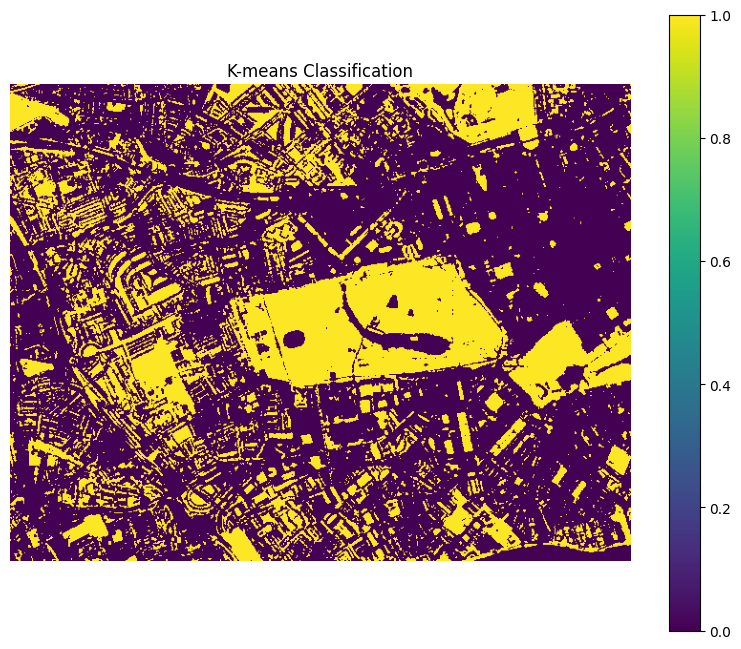

In [26]:
plt.figure(figsize=(10,8))

plt.imshow(cluster_map, cmap="viridis")

plt.title("K-means Classification")

plt.axis("off")

plt.colorbar()

plt.show()

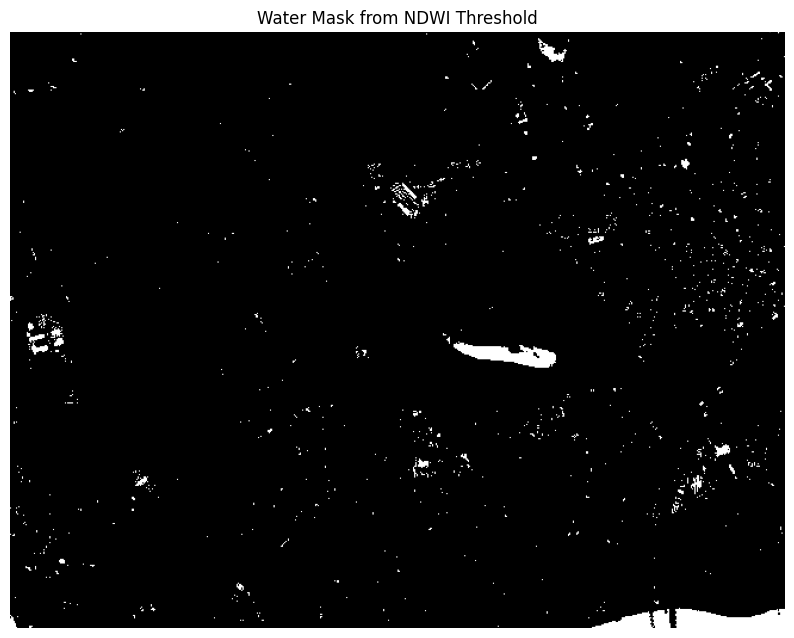

In [27]:
# Create water mask using NDWI threshold

water_mask_ndwi = ndwi_crop > 0

plt.figure(figsize=(10, 8))
plt.imshow(water_mask_ndwi, cmap="gray")
plt.title("Water Mask from NDWI Threshold")
plt.axis("off")
plt.show()

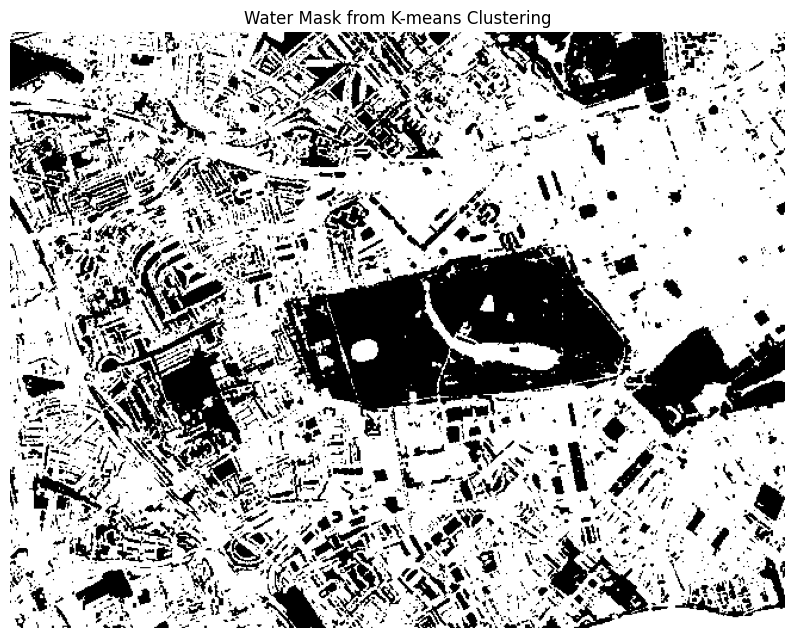

Water cluster: 0


In [28]:
# Identify the K-means cluster with the higher NDWI value as water

water_cluster = np.argmax(kmeans.cluster_centers_)
water_mask_kmeans = cluster_map == water_cluster

plt.figure(figsize=(10, 8))
plt.imshow(water_mask_kmeans, cmap="gray")
plt.title("Water Mask from K-means Clustering")
plt.axis("off")
plt.show()

print("Water cluster:", water_cluster)

In [29]:
np.sum(water_mask_ndwi)
np.sum(water_mask_kmeans)

np.int64(220745)

In [30]:
print("NDWI water pixels:", np.sum(water_mask_ndwi))
print("K-means water pixels:", np.sum(water_mask_kmeans))

NDWI water pixels: 5605
K-means water pixels: 220745


# Results and Discussion

The NDWI method successfully detected the Serpentine Lake and produced a relatively clean water mask.

The K-means clustering approach also identified the lake but classified many additional pixels as water.

The number of detected water pixels differed substantially between the two methods:

- NDWI water pixels: 5605
- K-means water pixels: 220745

This suggests that K-means overestimated water coverage in the urban environment.

Vegetation and shaded surfaces may have spectral characteristics similar to water, leading to misclassification.

Overall, NDWI provided a more realistic representation of the lake in this study area.

## Environmental Cost Assessment

This project uses freely available Sentinel-2 satellite imagery and cloud-based computing through Google Colab.

Compared with field surveys, remote sensing reduces the need for transportation and on-site data collection, which can lower carbon emissions.

However, machine learning algorithms and cloud computing require electricity and computational resources.

Although the environmental cost of this small project is relatively low, large-scale Earth observation and AI applications may have a higher energy demand.

Overall, the use of satellite imagery provides an efficient method for environmental monitoring while reducing the need for extensive fieldwork.

## Conclusion

This project investigated inland water detection in Hyde Park using Sentinel-2 imagery.

NDWI successfully identified the Serpentine Lake and produced a relatively accurate water mask.

K-means clustering detected the lake but also classified many urban pixels as water.

The results suggest that NDWI is more suitable for water detection in this urban environment.

Future work could explore additional spectral indices or supervised machine learning methods to improve classification accuracy.